In [4]:
import pandas as pd
df = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


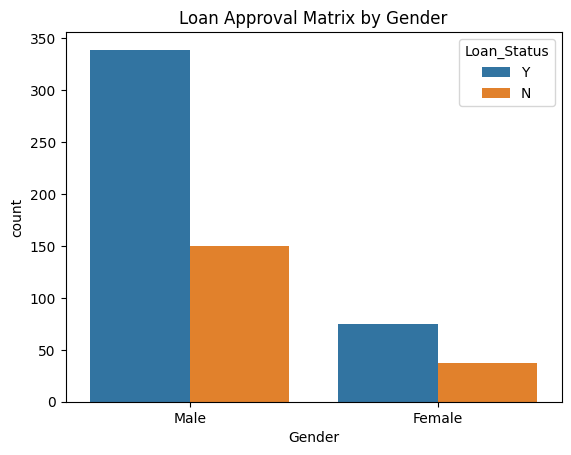

In [7]:
sns.countplot(x='Gender', hue='Loan_Status', data=df)
plt.title('Loan Approval Matrix by Gender')
plt.show()


In [8]:
pd.crosstab(df['Gender'], df['Loan_Status'], normalize='index') * 100


Loan_Status,N,Y
Gender,,
Female,33.035714,66.964286
Male,30.674847,69.325153


In [9]:
pd.crosstab(df['Credit_History'], df['Loan_Status'], normalize='index') * 100


Loan_Status,N,Y
Credit_History,,
0.0,92.134831,7.865169
1.0,20.421053,79.578947


In [10]:
df.isnull().sum()


,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [11]:
# Khali dabbon ko Mode aur Median se bharna
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

# Numerical columns ko median se bharna
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)

# Dobara check karna ke koi khali dabba bacha toh nahi
df.isnull().sum()


/tmp/ipykernel_2773/803828721.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_2773/803828721.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Un columns ko select karna jo text hain aur unhe 0/1 mein badalna
text_columns = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

for col in text_columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Ab check karte hain ke hamara ledger kaisa dikhta hai
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [ ]:
from sklearn.model_selection import train_test_split

# 1. Input variables (X) aur Target variable (y) alag karna
# Hum Loan_ID aur Loan_Status ko nikaal kar baqi sab X mein rakh rahe hain
X = df.drop(columns=['Loan_ID', 'Loan_Status'])
y = df['Loan_Status']

# 2. 80% data training ke liye aur 20% testing ke liye split karna
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data rows:", X_train.shape[0])
print("Testing data rows:", X_test.shape[0])


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. AI Model ka dabba tayaar karna
model = LogisticRegression(max_iter=1000)

# 2. Model ko training data de kar sikhana (Fitting the Matrix)
model.fit(X_train, y_train)

# 3. Model se unseen test data par exam (prediction) lena
y_pred = model.predict(X_test)

# 4. Accuracy check karna ke kitne percent jawab sahi diye
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"AI Model Accuracy: {accuracy:.2f}%")


NameError: name 'X_train' is not defined

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Inputs aur Target ko final clean kar ke alag karna
X = df.drop(columns=['Loan_ID', 'Loan_Status'])
y = df['Loan_Status']

# 2. Train-Test Split karna (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. AI Model ko tayaar karna aur sikhana
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 4. Accuracy check karna
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"AI Model Accuracy: {accuracy:.2f}%")


ValueError: could not convert string to float: '3+'

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. '3+' ko simple number 3 mein badalna taake maths kharab na ho
df['Dependents'] = df['Dependents'].replace('3+', 3)

# 2. Agar koi bhi khali dabba bacha ho toh use safe value se bharna
df = df.fillna(0)

# 3. Inputs (X) aur Target (y) ko alag karna
X = df.drop(columns=['Loan_ID', 'Loan_Status'])
y = df['Loan_Status']

# 4. Train-Test Split (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. AI Model Training
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 6. Final Evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"🎉 AI Model Accuracy: {accuracy:.2f}%")


🎉 AI Model Accuracy: 78.86%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Zip file extraction
!unzip -o archive.zip

# 2. Data load karna sahi naam k sath
df = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')

# 3. Data Cleaning (3+ fix aur missing values treatment)
df['Dependents'] = df['Dependents'].replace('3+', 3)
df = df.fillna(0)

# 4. Encoding (Text ko numerical vector values mein badalna)
text_columns = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in text_columns:
    df[col] = le.fit_transform(df[col].astype(str))

# 5. Model Training (80/20 train-test splitting)
X = df.drop(columns=['Loan_ID', 'Loan_Status'])
y = df['Loan_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 6. Print final result
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"🎉 Final Verified Portfolio Model Accuracy: {accuracy:.2f}%")
df.head()


Archive:  archive.zip
  inflating: test_Y3wMUE5_7gLdaTN.csv  
  inflating: train_u6lujuX_CVtuZ9i.csv  
🎉 Final Verified Portfolio Model Accuracy: 77.24%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,2,1,0,0,1,5849,0.0,0.0,360.0,1.0,2,1
1,LP001003,2,2,1,0,1,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,2,2,0,0,2,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,2,2,0,1,1,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,2,1,0,0,1,6000,0.0,141.0,360.0,1.0,2,1
